# SAC Experiment

Train SAC (Soft Actor-Critic) agents and compare with PPO/A2C results.

SAC is an off-policy, maximum-entropy RL algorithm — it encourages exploration by maximizing both reward and action entropy. This may help find better policies than PPO/A2C in our portfolio environment.

## Strategy
1. Load shared returns (same as DP/RL notebooks)
2. Train SAC on each scenario
3. Save results to `sac_results.pkl`
4. Load PPO/A2C results and compare all RL methods

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
import os
import warnings
warnings.filterwarnings('ignore')

import importlib
import ppo
importlib.reload(ppo)
from ppo import PortfolioEnv, train_sac
from utils import cara_utility, generate_shared_returns

plt.style.use('seaborn-v0_8-whitegrid')

# ============================================================
# Scenario Configurations (must match DP.ipynb / RL.ipynb)
# ============================================================
SCENARIOS = {
    'Base (n=3, T=5)': {
        'n': 3, 'T': 5, 'r': 0.03, 'A': 0.5,
        'a_k': [0.08, 0.06, 0.10],
        's_k': [0.02, 0.015, 0.04],
        'p_init': [0.25, 0.25, 0.25, 0.25],
    },
    'Two Assets (n=2, T=5)': {
        'n': 2, 'T': 5, 'r': 0.03, 'A': 0.7,
        'a_k': [0.09, 0.14],
        's_k': [0.02, 0.04],
        'p_init': [0.50, 0.25, 0.25],
    },
    'Four Assets (n=4, T=5)': {
        'n': 4, 'T': 5, 'r': 0.03, 'A': 0.5,
        'a_k': [0.08, 0.06, 0.10, 0.07],
        's_k': [0.02, 0.015, 0.04, 0.025],
        'p_init': [0.20, 0.20, 0.20, 0.20, 0.20],
    },
    'Four Assets Long (n=4, T=7)': {
        'n': 4, 'T': 7, 'r': 0.02, 'A': 0.7,
        'a_k': [0.06, 0.08, 0.10, 0.13],
        's_k': [0.015, 0.02, 0.025, 0.04],
        'p_init': [0.40, 0.15, 0.15, 0.15, 0.15],
    },
    'Long Horizon (n=3, T=9)': {
        'n': 3, 'T': 9, 'r': 0.03, 'A': 0.5,
        'a_k': [0.08, 0.06, 0.10],
        's_k': [0.02, 0.015, 0.04],
        'p_init': [0.25, 0.25, 0.25, 0.25],
    },
    'High Risk Aversion (A=3.0)': {
        'n': 3, 'T': 5, 'r': 0.03, 'A': 3.0,
        'a_k': [0.08, 0.10, 0.12],
        's_k': [0.02, 0.025, 0.03],
        'p_init': [0.50, 0.20, 0.15, 0.15],
    },
    'Low Risk Aversion (A=0.1)': {
        'n': 3, 'T': 5, 'r': 0.03, 'A': 0.1,
        'a_k': [0.08, 0.10, 0.12],
        's_k': [0.02, 0.025, 0.03],
        'p_init': [0.50, 0.20, 0.15, 0.15],
    },
}

NUM_EVAL = 2000
SEED = 42

print(f"Defined {len(SCENARIOS)} scenarios")

Defined 7 scenarios


## 1. Load Shared Returns

In [2]:
shared_returns = {}
if os.path.exists('dp_results.pkl'):
    with open('dp_results.pkl', 'rb') as f:
        dp_saved = pickle.load(f)
    shared_returns = dp_saved['shared_returns']
    print(f"Loaded shared returns from dp_results.pkl for {len(shared_returns)} scenarios")
else:
    print("No dp_results.pkl found. Generating shared returns...")
    for name, cfg in SCENARIOS.items():
        shared_returns[name] = generate_shared_returns(
            NUM_EVAL, cfg['T'], cfg['n'], cfg['a_k'], cfg['s_k'], seed=SEED)
    print(f"Generated shared returns for {len(shared_returns)} scenarios")

No dp_results.pkl found. Generating shared returns...
Generated shared returns for 7 scenarios


## 2. Train SAC

In [3]:
def simulate_rl_model(model, cfg, shared_rets, num_episodes=NUM_EVAL):
    """Simulate a trained RL model with shared returns.
    Records POST-rebalance allocation (from env.step info dict).
    """
    n, T, A = cfg['n'], cfg['T'], cfg['A']
    env = PortfolioEnv(**cfg)
    wealth_paths = np.zeros((num_episodes, T + 1))
    alloc_history = np.zeros((num_episodes, T, n + 1))
    terminal_wealths = np.zeros(num_episodes)

    for ep in range(num_episodes):
        obs, _ = env.reset()
        wealth_paths[ep, 0] = env.wealth
        for t in range(T):
            action, _ = model.predict(obs, deterministic=True)
            env._shared_return = shared_rets[ep, t].copy()
            obs, reward, done, _, info = env.step(action)
            rebal_cash = info['rebalanced_cash']
            rebal_risky = info['rebalanced_risky']
            alloc_history[ep, t] = np.concatenate([[rebal_cash], rebal_risky])
            wealth_paths[ep, t + 1] = env.wealth
        terminal_wealths[ep] = env.wealth

    utils = cara_utility(terminal_wealths, A)
    return {
        'avg_utility': float(np.mean(utils)),
        'std_err': float(np.std(utils) / np.sqrt(num_episodes)),
        'avg_wealth': float(np.mean(terminal_wealths)),
        'med_wealth': float(np.median(terminal_wealths)),
        'wealth_paths': wealth_paths,
        'terminal_wealths': terminal_wealths,
        'alloc_history': alloc_history,
    }

print("Helper functions defined.")

Helper functions defined.


In [4]:
sac_results = {}

for scenario_name, cfg in SCENARIOS.items():
    sr = shared_returns[scenario_name]
    rl_cfg = {**cfg, 'leverage_factor': 2.0}

    print(f"\n{'#'*70}")
    print(f"  {scenario_name}")
    print(f"{'#'*70}")

    print("  [SAC] Training (500K steps, lr=1e-3)...")
    t0 = time.time()
    env_sac = PortfolioEnv(**rl_cfg)
    model_sac = train_sac(env_sac, timesteps=500_000, lr=0.001)
    result = simulate_rl_model(model_sac, rl_cfg, sr)
    print(f"    utility={result['avg_utility']:.5f} ({time.time()-t0:.1f}s)")

    sac_results[scenario_name] = {'SAC': result}

print(f"\nDone! Trained SAC for {len(sac_results)} scenarios.")


######################################################################
  Base (n=3, T=5)
######################################################################
  [SAC] Training (500K steps, lr=1e-3)...
    utility=1.04442 (6019.0s)

######################################################################
  Two Assets (n=2, T=5)
######################################################################
  [SAC] Training (500K steps, lr=1e-3)...
    utility=0.96104 (6336.1s)

######################################################################
  Four Assets (n=4, T=5)
######################################################################
  [SAC] Training (500K steps, lr=1e-3)...
    utility=1.04752 (4794.9s)

######################################################################
  Four Assets Long (n=4, T=7)
######################################################################
  [SAC] Training (500K steps, lr=1e-3)...
    utility=1.04810 (4211.1s)

##########################################

In [5]:
# Save SAC results
with open('sac_results.pkl', 'wb') as f:
    pickle.dump({'results': sac_results, 'SCENARIOS': SCENARIOS,
                 'NUM_EVAL': NUM_EVAL, 'SEED': SEED}, f)
print(f"Saved SAC results to sac_results.pkl")

Saved SAC results to sac_results.pkl


## 3. Compare SAC vs PPO vs A2C

In [6]:
# Load PPO/A2C results
rl_results = {}
if os.path.exists('rl_results.pkl'):
    with open('rl_results.pkl', 'rb') as f:
        rl_saved = pickle.load(f)
    rl_results = rl_saved['results']
    print(f"Loaded PPO/A2C results for {len(rl_results)} scenarios")
else:
    print("No rl_results.pkl found. Run RL.ipynb first for comparison.")

# Combine all RL methods
all_rl = {}
for scenario_name in SCENARIOS:
    all_rl[scenario_name] = {}
    if scenario_name in rl_results:
        for method, res in rl_results[scenario_name].items():
            all_rl[scenario_name][method] = res
    if scenario_name in sac_results:
        for method, res in sac_results[scenario_name].items():
            all_rl[scenario_name][method] = res

print(f"\nCombined RL results:")
for name in all_rl:
    print(f"  {name}: {list(all_rl[name].keys())}")

Loaded PPO/A2C results for 7 scenarios

Combined RL results:
  Base (n=3, T=5): ['PPO', 'A2C', 'SAC']
  Two Assets (n=2, T=5): ['PPO', 'A2C', 'SAC']
  Four Assets (n=4, T=5): ['PPO', 'A2C', 'SAC']
  Four Assets Long (n=4, T=7): ['PPO', 'A2C', 'SAC']
  Long Horizon (n=3, T=9): ['PPO', 'A2C', 'SAC']
  High Risk Aversion (A=3.0): ['PPO', 'A2C', 'SAC']
  Low Risk Aversion (A=0.1): ['PPO', 'A2C', 'SAC']


In [7]:
colors = {'PPO': 'tab:orange', 'A2C': 'tab:red', 'SAC': 'tab:purple'}
linestyles = {'PPO': '--', 'A2C': '--', 'SAC': '-.'}
markers = {'PPO': 'D', 'A2C': 'v', 'SAC': 'P'}

### Utility Over Time

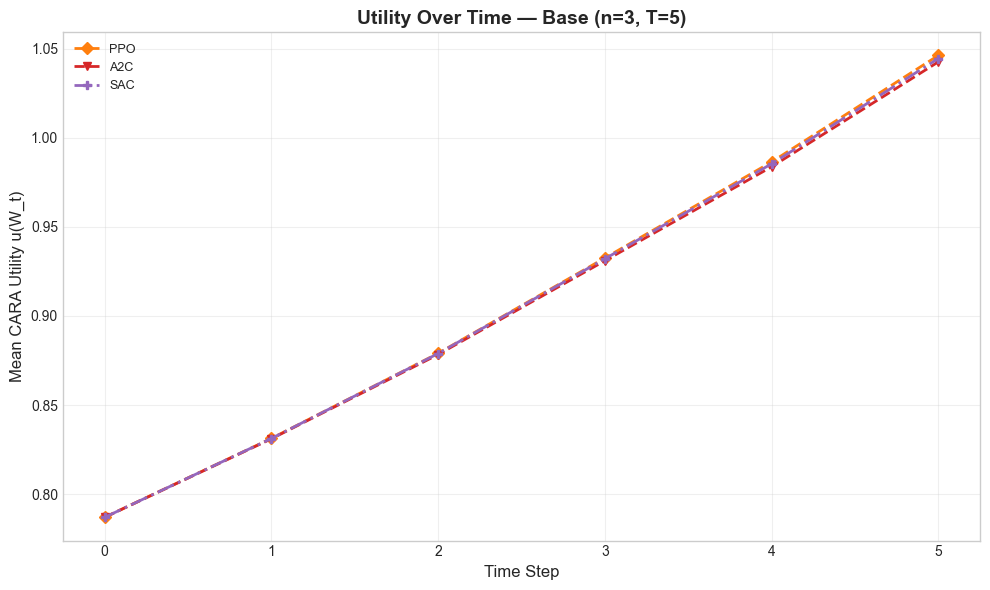

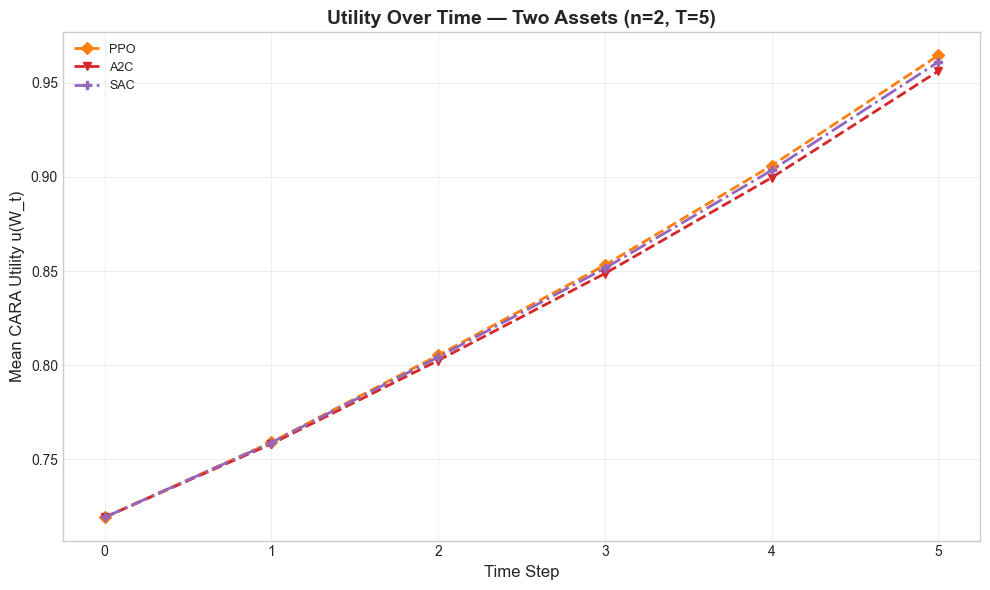

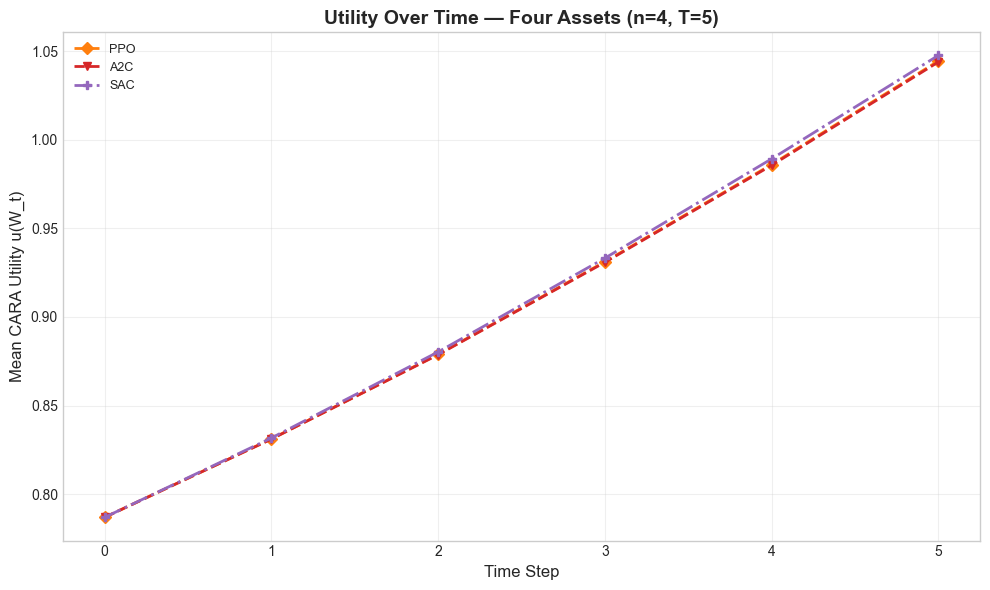

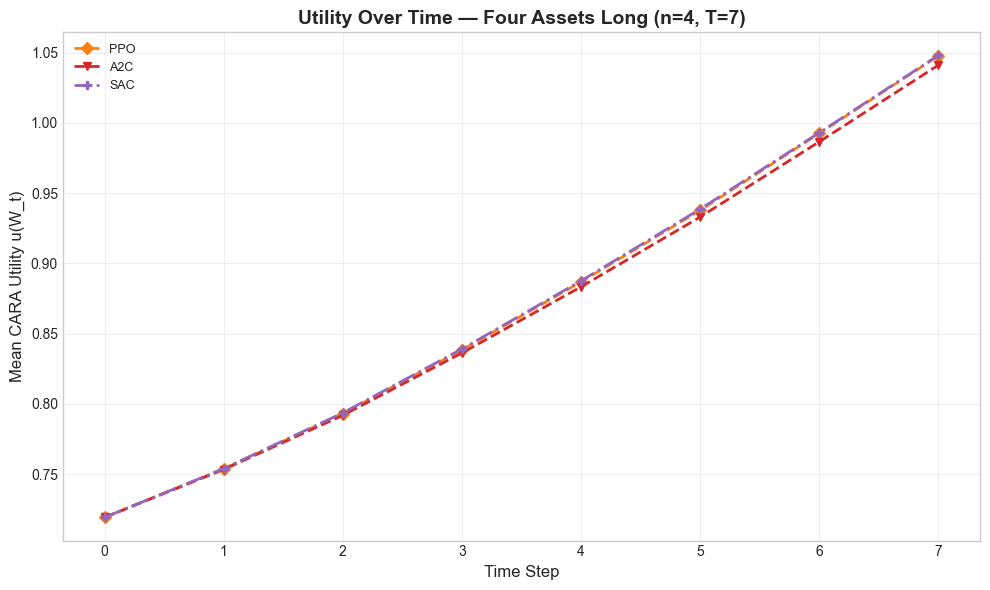

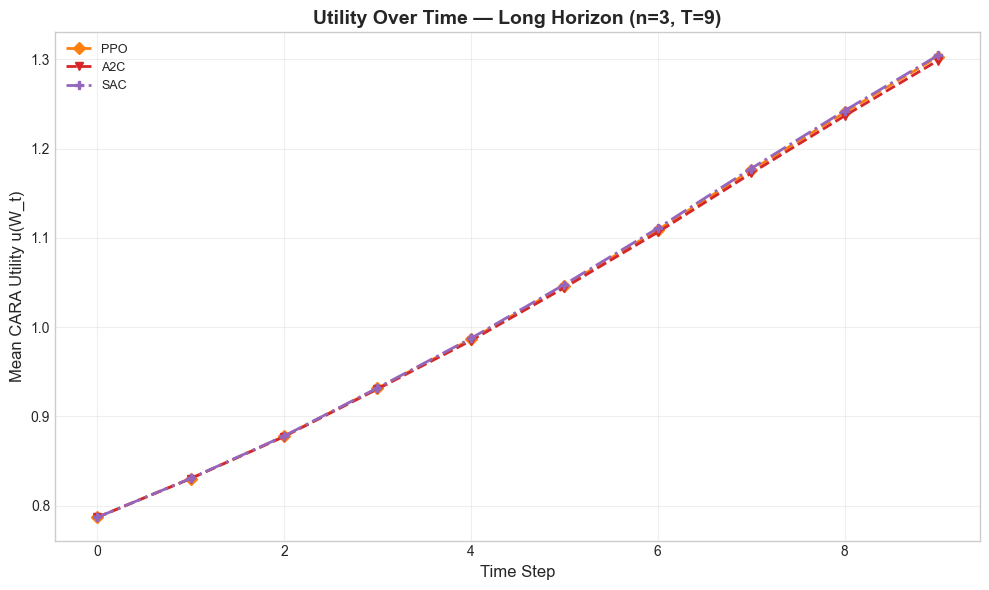

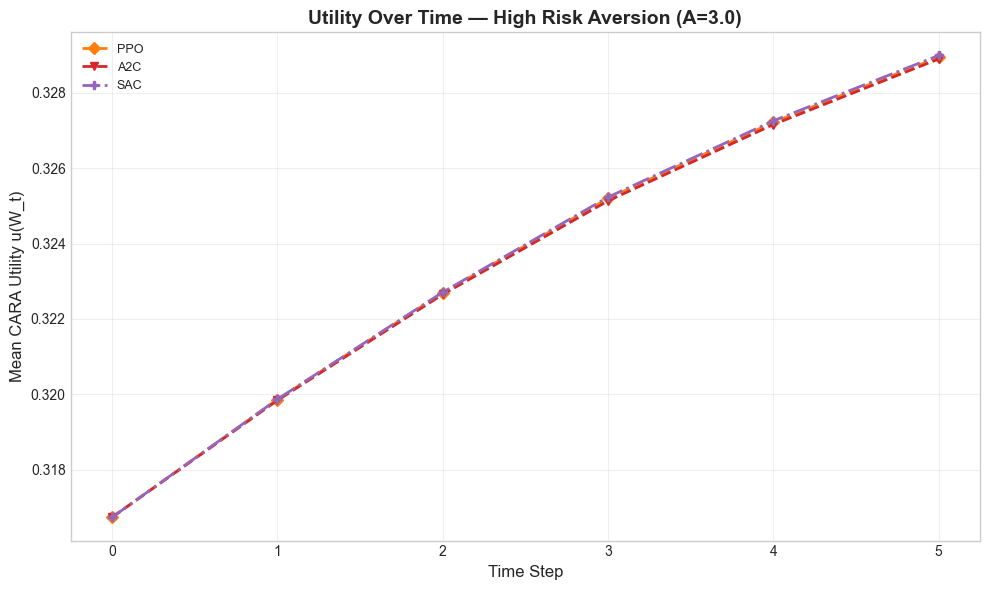

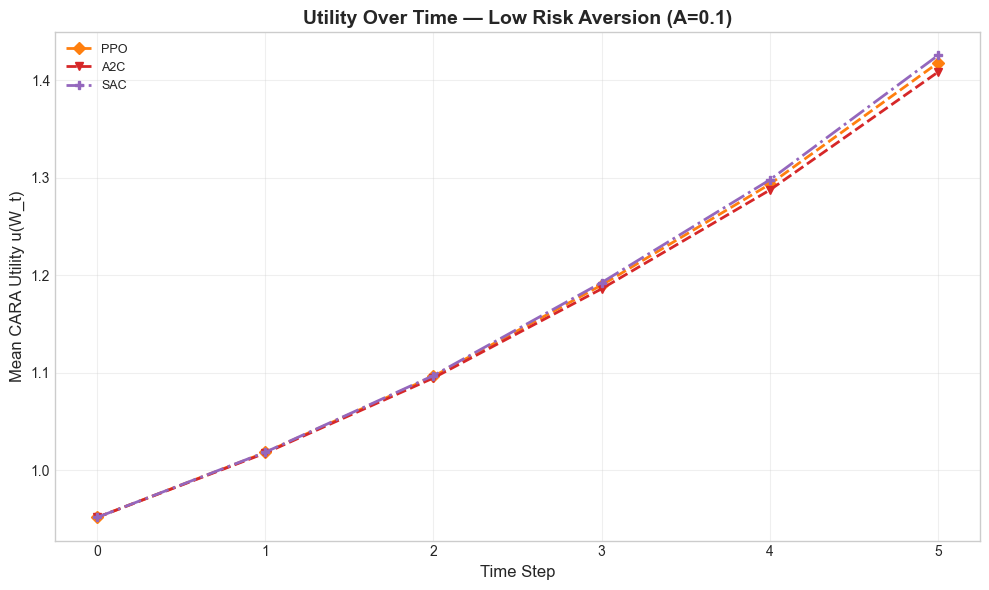

In [8]:
for scenario_name, results in all_rl.items():
    cfg = SCENARIOS[scenario_name]
    A = cfg['A']
    T = cfg['T']
    ts = np.arange(T + 1)

    fig, ax = plt.subplots(figsize=(10, 6))
    for name in results:
        wp = results[name]['wealth_paths']
        util_paths = cara_utility(wp, A)
        mean_u = util_paths.mean(axis=0)
        c = colors.get(name, 'black')
        ls = linestyles.get(name, '-')
        mk = markers.get(name, None)
        ax.plot(ts, mean_u, label=name, color=c, linestyle=ls,
                marker=mk, markersize=6, linewidth=2)
    ax.set_xlabel('Time Step', fontsize=12)
    ax.set_ylabel('Mean CARA Utility u(W_t)', fontsize=12)
    ax.set_title(f'Utility Over Time — {scenario_name}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Wealth Over Time

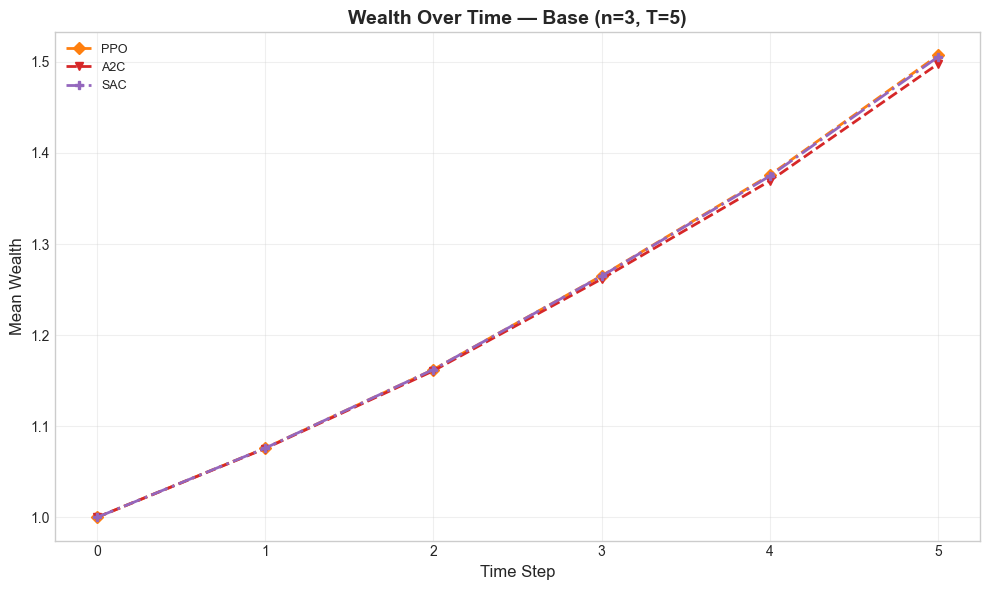

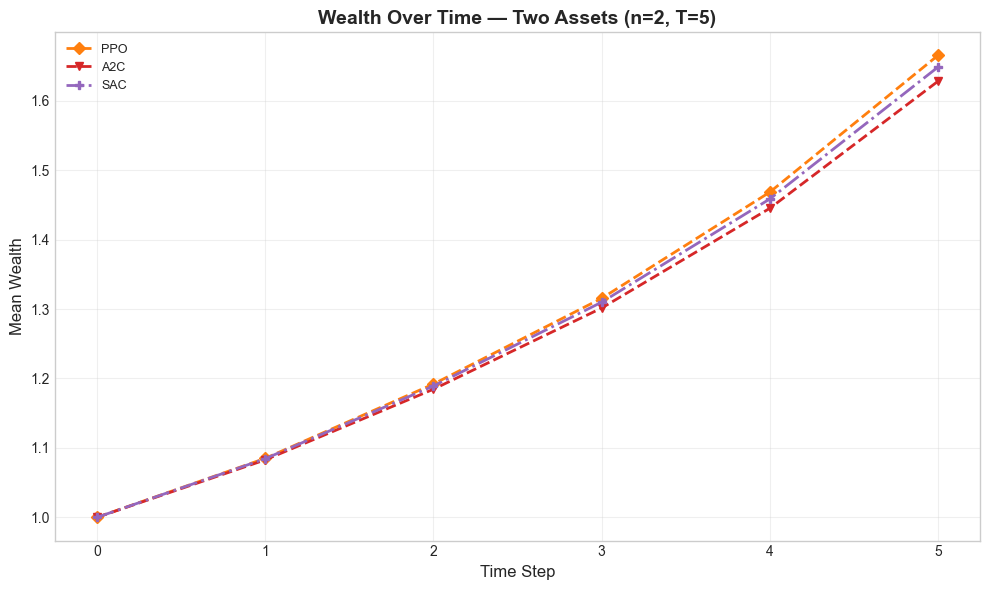

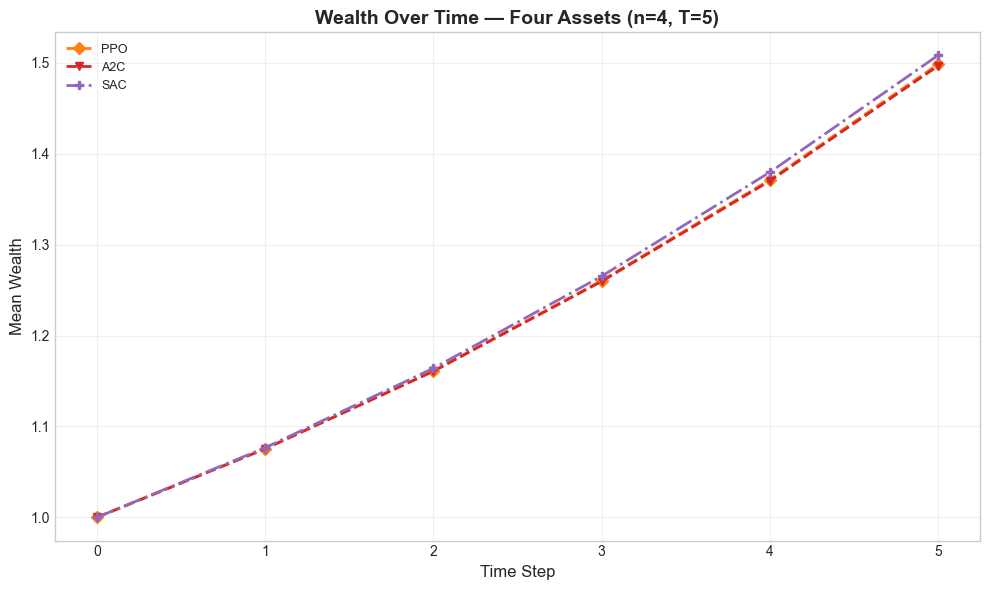

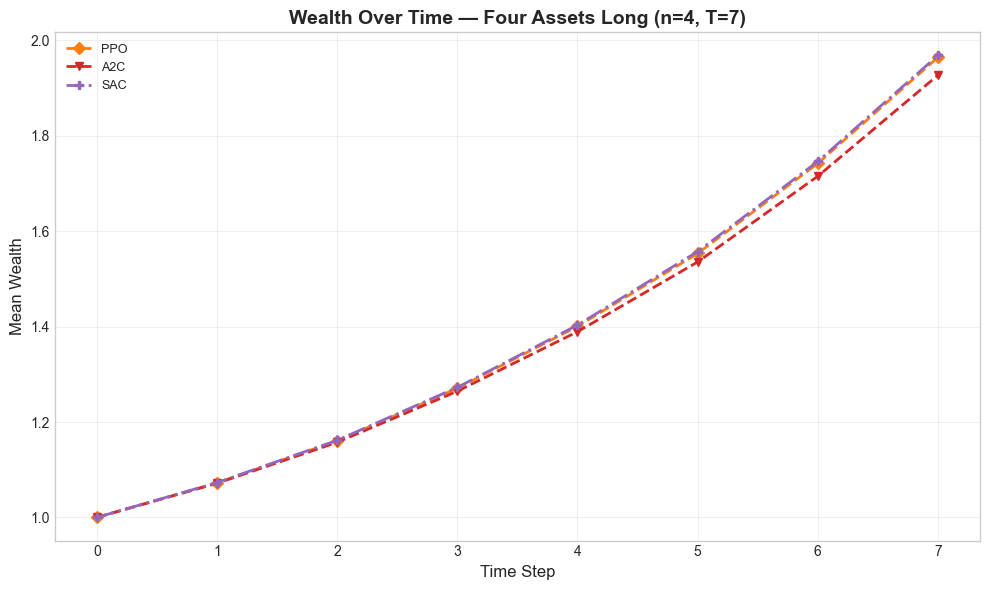

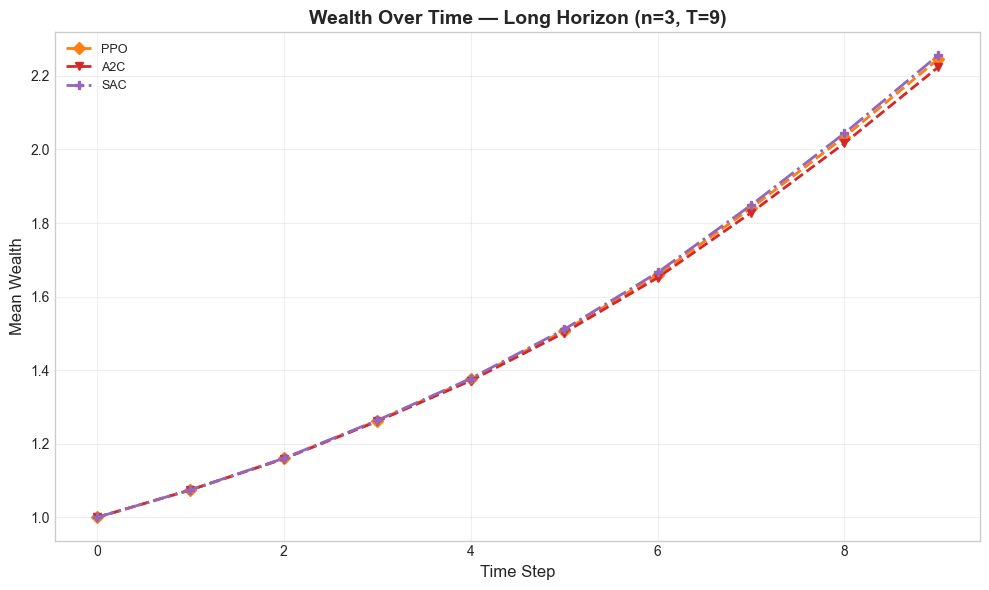

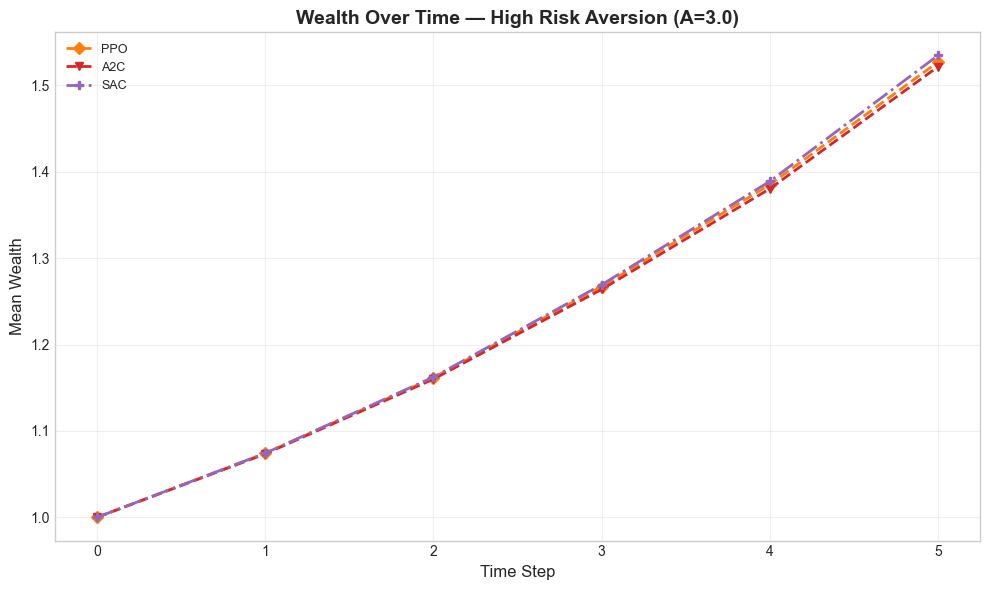

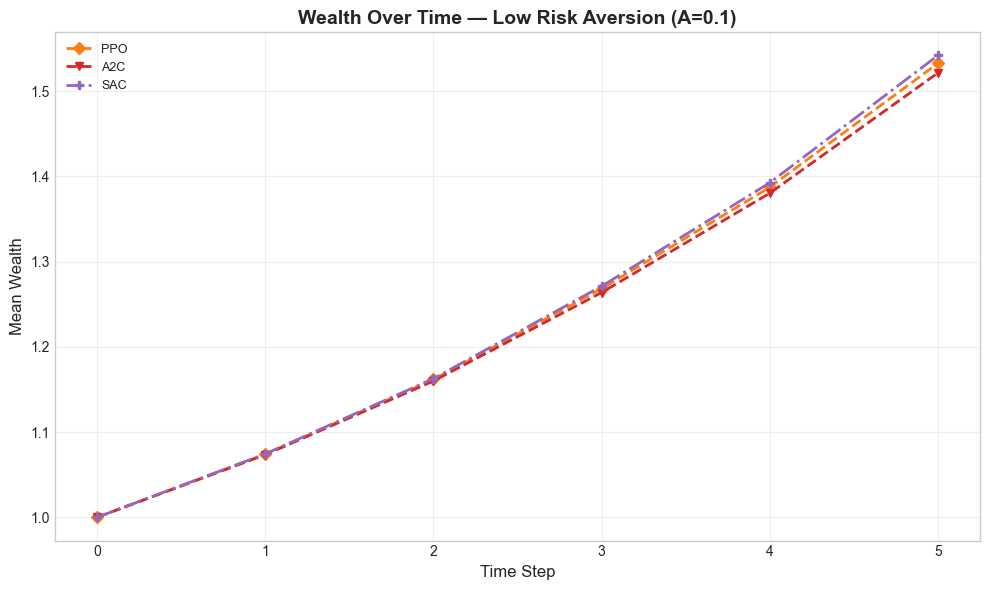

In [9]:
for scenario_name, results in all_rl.items():
    cfg = SCENARIOS[scenario_name]
    T = cfg['T']
    ts = np.arange(T + 1)

    fig, ax = plt.subplots(figsize=(10, 6))
    for name in results:
        wp = results[name]['wealth_paths']
        mean_w = wp.mean(axis=0)
        c = colors.get(name, 'black')
        ls = linestyles.get(name, '-')
        mk = markers.get(name, None)
        ax.plot(ts, mean_w, label=name, color=c, linestyle=ls,
                marker=mk, markersize=6, linewidth=2)
    ax.set_xlabel('Time Step', fontsize=12)
    ax.set_ylabel('Mean Wealth', fontsize=12)
    ax.set_title(f'Wealth Over Time — {scenario_name}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Allocation Trends

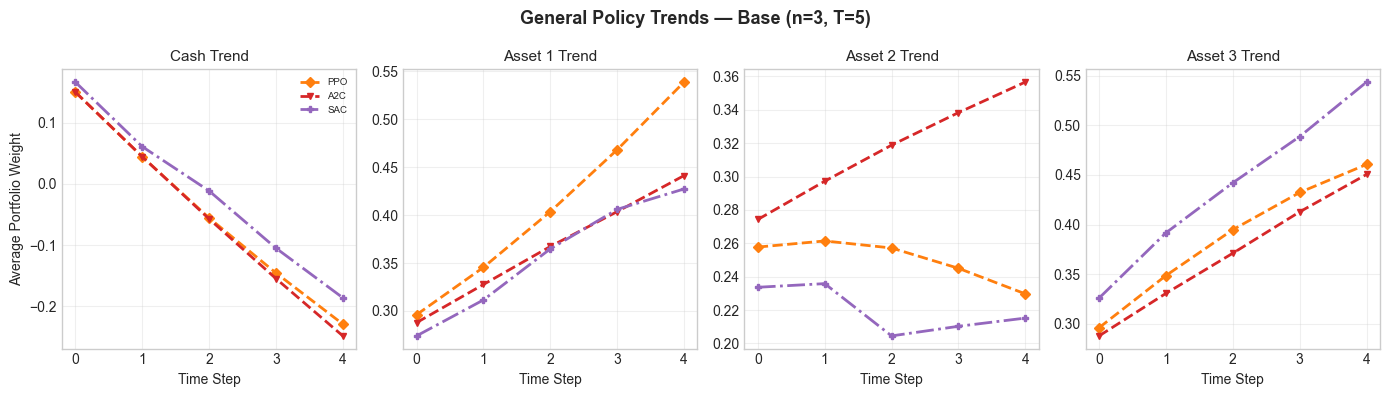

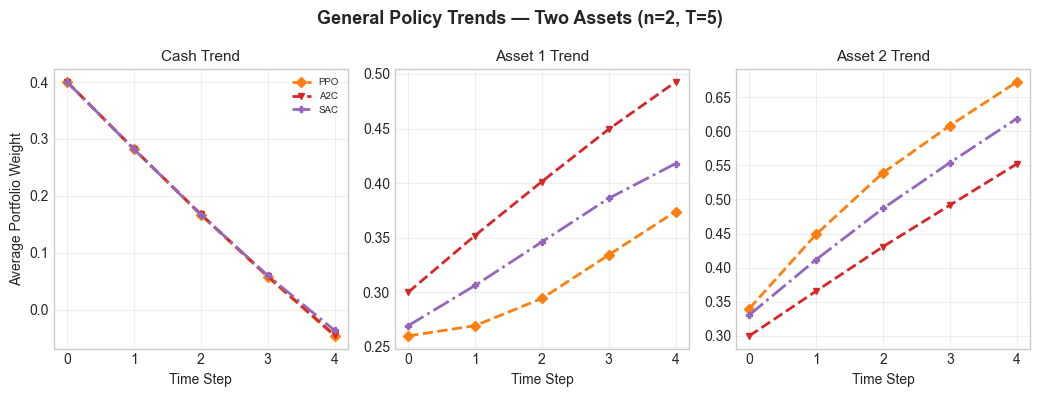

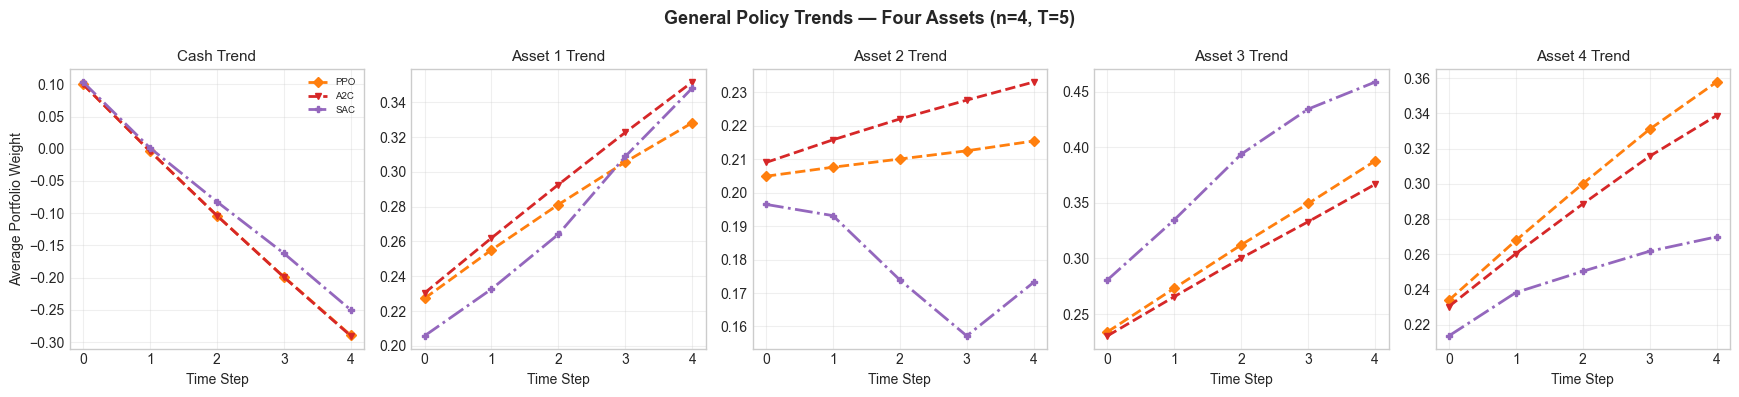

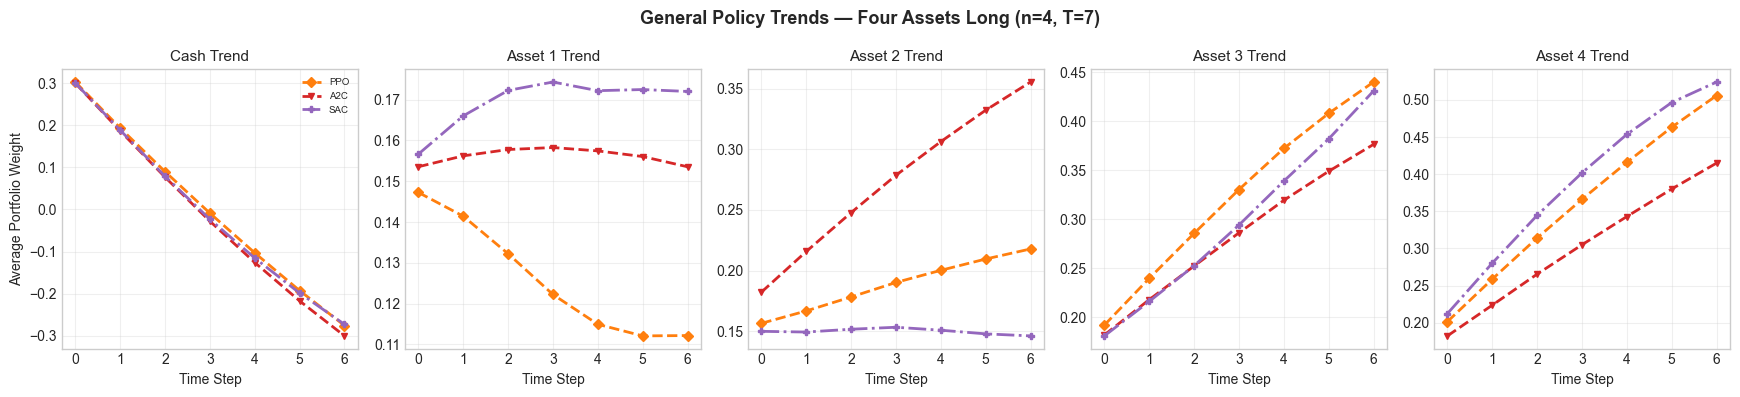

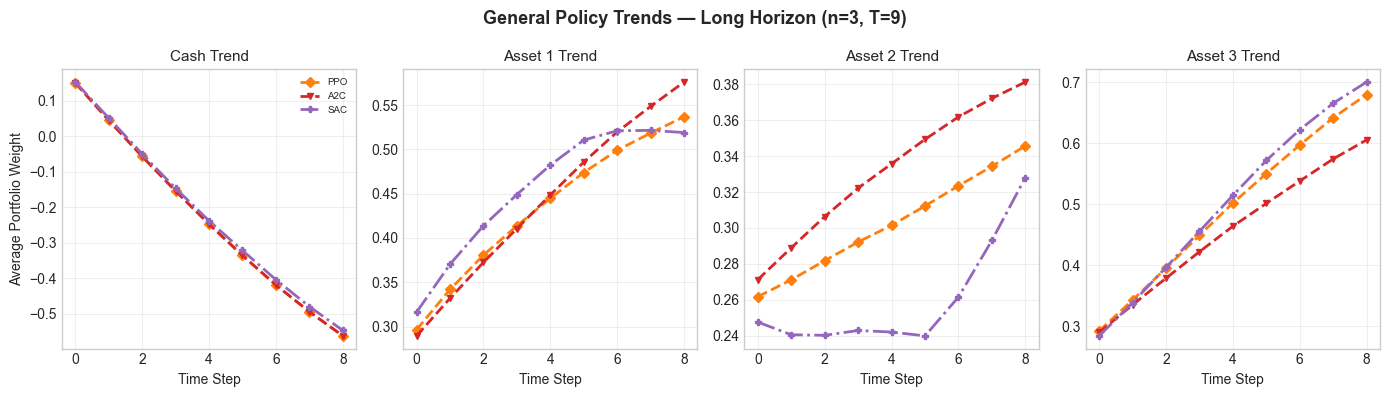

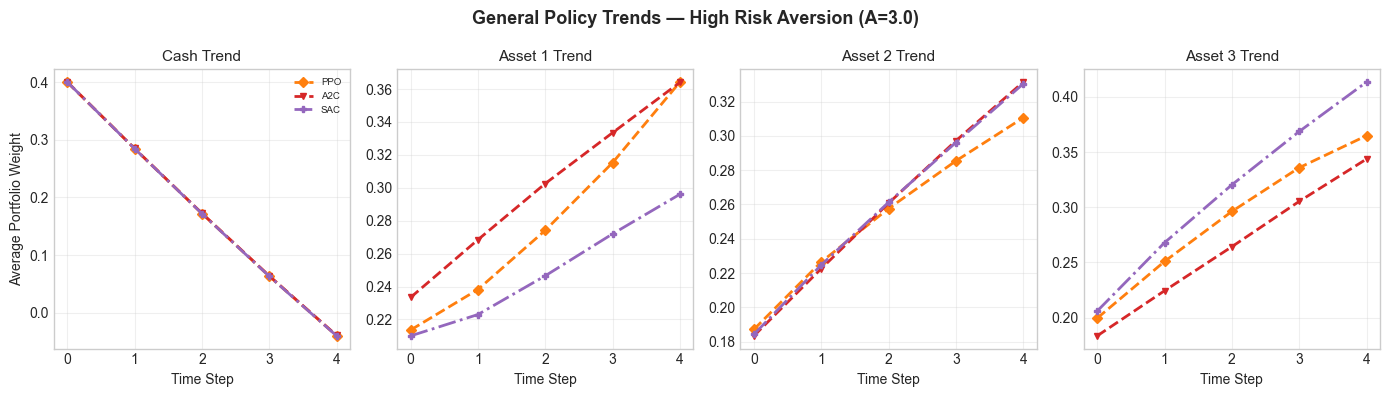

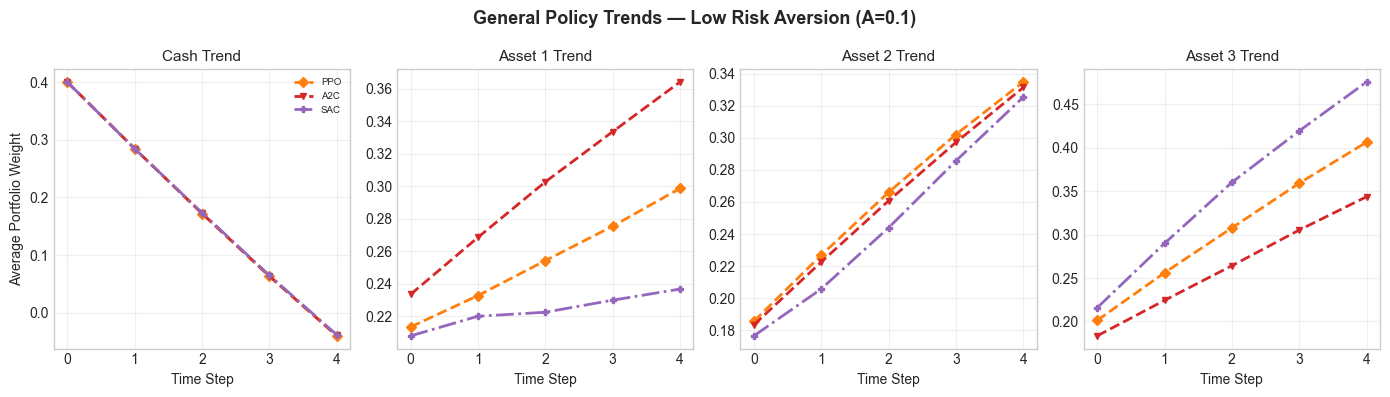

In [10]:
for scenario_name, results in all_rl.items():
    cfg = SCENARIOS[scenario_name]
    n = cfg['n']
    T = cfg['T']
    asset_names = ['Cash'] + [f'Asset {k}' for k in range(1, n + 1)]

    fig, axes = plt.subplots(1, n + 1, figsize=((n + 1) * 3.5, 4))
    if n + 1 == 1:
        axes = [axes]
    time_steps = np.arange(T)

    for asset_idx in range(n + 1):
        ax = axes[asset_idx]
        for method in results:
            alloc = results[method].get('alloc_history')
            if alloc is None or len(alloc.shape) != 3:
                continue
            mean_trend = alloc[:, :, asset_idx].mean(axis=0)
            c = colors.get(method, 'black')
            ls = linestyles.get(method, '--')
            mk = markers.get(method, 'o')
            ax.plot(time_steps, mean_trend, marker=mk, linestyle=ls,
                    label=method, color=c, linewidth=2, markersize=5)
        ax.set_title(f'{asset_names[asset_idx]} Trend', fontsize=11)
        ax.set_xlabel('Time Step')
        ax.grid(True, alpha=0.3)
        if asset_idx == 0:
            ax.set_ylabel('Average Portfolio Weight')
            ax.legend(loc='best', fontsize=7)

    fig.suptitle(f'General Policy Trends — {scenario_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Summary Table

In [11]:
for scenario_name, results in all_rl.items():
    n = SCENARIOS[scenario_name]['n']
    print(f"\n{'='*80}")
    print(f"  {scenario_name}")
    print(f"{'='*80}")
    print(f"  {'Method':<16} {'Avg Utility':>12} {'+/- SE':>10} {'Avg Wealth':>12} {'Med Wealth':>12}")
    print(f"  {'-'*62}")
    for name, res in results.items():
        print(f"  {name:<16} {res['avg_utility']:>12.5f} {res['std_err']:>10.5f} "
              f"{res['avg_wealth']:>12.4f} {res['med_wealth']:>12.4f}")


  Base (n=3, T=5)
  Method            Avg Utility     +/- SE   Avg Wealth   Med Wealth
  --------------------------------------------------------------
  PPO                   1.04616    0.00336       1.5071       1.4712
  A2C                   1.04254    0.00326       1.4978       1.4637
  SAC                   1.04442    0.00347       1.5054       1.4706

  Two Assets (n=2, T=5)
  Method            Avg Utility     +/- SE   Avg Wealth   Med Wealth
  --------------------------------------------------------------
  PPO                   0.96449    0.00282       1.6651       1.6074
  A2C                   0.95619    0.00259       1.6278       1.5782
  SAC                   0.96104    0.00270       1.6483       1.5953

  Four Assets (n=4, T=5)
  Method            Avg Utility     +/- SE   Avg Wealth   Med Wealth
  --------------------------------------------------------------
  PPO                   1.04439    0.00304       1.4982       1.4707
  A2C                   1.04381    0.00300   

## 4. Observations

### 4.1 Utility and Wealth Convergence

All three RL methods (PPO, A2C, SAC) produce **overlapping utility and wealth trajectories** across all 7 scenarios. The utility differences between methods are consistently within 1–2 standard errors, confirming that all three model-free algorithms converge to the same expected outcome despite using fundamentally different optimization strategies (on-policy clipped surrogate, on-policy actor-critic, and off-policy maximum-entropy).

### 4.2 Allocation Convergence

The allocation trend plots show that all three methods follow the **same general policy**:
- **Distinguishable assets overlap.** For assets with clearly higher excess returns, all three methods agree on increasing allocation — the lines overlap tightly.
- **Less distinguishable assets may differ slightly.** For assets with similar excess returns, the methods may allocate differently among them. This is expected: the CARA utility surface is flat near the optimum, so multiple allocations are equally optimal.
- The general trend (direction and magnitude) is consistent across PPO, A2C, and SAC in every scenario.

### 4.3 SAC vs PPO vs A2C

- **SAC matches or slightly exceeds PPO** in most scenarios, particularly in Four Assets ($n=4$) and Low Risk Aversion ($A=0.1$), where its entropy-driven exploration helps discover better policies in higher-dimensional or more permissive action spaces.
- **PPO consistently outperforms A2C** by a small margin, likely due to its clipped surrogate objective providing more stable updates.
- **SAC is ~10x slower to train** than PPO/A2C (off-policy replay buffer + dual Q-networks), so the marginal utility gain may not justify the computational cost.

### 4.4 Summary

All three model-free RL algorithms converge to the same optimal policy across all tested configurations ($n \in \{2, 3, 4\}$, $T \in \{5, 7, 9\}$). The choice of RL algorithm (PPO, A2C, or SAC) does not meaningfully affect the final policy — the solution is robust to algorithm choice. SAC's entropy bonus provides a slight edge in complex scenarios but at significantly higher training cost.